In [6]:
# !pip install databento
# !pip install xgboost

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import time
from zoneinfo import ZoneInfo

import databento as db
from arch import arch_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [8]:
features = pd.read_csv("mbp10_bid_ask_features_30min.csv", header=[0,1], index_col=0, parse_dates=True)
features
tickers = ["RRC","APA","AR","EQT"]

for sym in features.columns.get_level_values(0).unique():
    mid = features[(sym, "mid")].astype(float)
    fwd = mid.shift(-1)
    log_ret = np.log(fwd) - np.log(mid)
    features[(sym, "log_ret")] = log_ret
    features[(sym, "ret_sq")] = log_ret**2
features = features[features.index.time != pd.to_datetime("16:00").time()]

for tk in tickers:
    features.loc[:, (tk, "ret_sq")] = features.loc[:, (tk, "log_ret")].astype(float) ** 2
features.sort_index(axis=1, level=0, inplace=True)
tickers = ["RRC","APA","AR","EQT"]

for tk in tickers:
    s = features[tk]["ret_sq"].astype(float)
    lower, upper = s.quantile([0.01, 0.99])
    features.loc[:, (tk, "ret_sq")] = s.clip(lower, upper)

features.dropna(inplace=True)


In [9]:
def split_panel_one_model(df: pd.DataFrame, target="ret_sq", test_size=0.2):
    tickers = df.columns.get_level_values(0).unique()
    parts = []
    for t in tickers:
        s = df[t].copy()
        s["ticker"] = t
        s["timestamp"] = s.index
        parts.append(s)
    panel = pd.concat(parts).sort_values("timestamp")
    times = np.asarray(sorted(panel["timestamp"].unique()))
    k = int(np.floor(len(times) * (1 - test_size)))
    cutoff = times[k]
    y = panel[target]
    X = panel.drop(columns=[target])
    if "log_ret" in X.columns:
        X = X.drop(columns=["log_ret"])
    else:
        X = X.loc[:, ~X.columns.get_level_values(-1).isin(["log_ret"])]
    X = pd.get_dummies(X, columns=["ticker"], drop_first=False)
    mask_tr = panel["timestamp"] < cutoff
    mask_te = panel["timestamp"] >= cutoff
    X_tr, X_te = X.loc[mask_tr].drop(columns=["timestamp"]), X.loc[mask_te].drop(columns=["timestamp"])
    y_tr, y_te = y.loc[mask_tr], y.loc[mask_te]
    m1 = X_tr.notna().all(1) & y_tr.notna()
    m2 = X_te.notna().all(1) & y_te.notna()
    return X_tr[m1], X_te[m2], y_tr[m1], y_te[m2]


In [10]:
def evaluate_linear_reg(df, target="ret_sq", test_size=0.2):
    X_tr, X_te, y_tr, y_te = split_panel_one_model(df, target=target, test_size=test_size)

    results = {}
    tickers = df.columns.get_level_values(0).unique()

    lr = LinearRegression()
    lr.fit(X_tr, y_tr)
    y_pred_all = lr.predict(X_te)
    results["overall"] = {
        "MSE": mean_squared_error(y_te, y_pred_all)
    }

    X_tr_sm = sm.add_constant(X_tr.astype(float))
    ols_model = sm.OLS(y_tr.astype(float), X_tr_sm).fit()
    summary = ols_model.summary()

    for t in tickers:
        col = f"ticker_{t}"
        if col not in X_tr.columns:
            continue
        mask_tr = X_tr[col] == 1
        mask_te = X_te[col] == 1
        if mask_tr.sum() == 0 or mask_te.sum() == 0:
            continue
        lr_t = LinearRegression()
        lr_t.fit(X_tr[mask_tr], y_tr[mask_tr])
        y_pred = lr_t.predict(X_te[mask_te])
        results[t] = {
            "MSE": mean_squared_error(y_te[mask_te], y_pred)
        }

    return pd.DataFrame(results).T, summary

In [11]:
results, summary = evaluate_linear_reg(features, target="ret_sq", test_size=0.2)
print(results)
print(summary)


                  MSE
overall  4.148626e-07
APA      2.008520e-06
AR       9.279500e-08
EQT      5.962239e-08
RRC      9.969976e-08
                            OLS Regression Results                            
Dep. Variable:                 ret_sq   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     37.16
Date:                Wed, 10 Sep 2025   Prob (F-statistic):           4.04e-88
Time:                        18:02:10   Log-Likelihood:                 16144.
No. Observations:                3224   AIC:                        -3.226e+04
Df Residuals:                    3210   BIC:                        -3.217e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025    

In [12]:
features_to_plot = ["best_price.ASK", "best_size.ASK", "depth_notional.ASK", "depth_size.ASK"]

X_tr, X_te, y_tr, y_te = split_panel_one_model(features, target="ret_sq", test_size=0.2)
lr = LinearRegression().fit(X_tr, y_tr)
resid = y_te - lr.predict(X_te)

tickers = features.columns.get_level_values(0).unique()

for t in tickers:
    mask_te = X_te[f"ticker_{t}"] == 1 if f"ticker_{t}" in X_te.columns else None
    if mask_te is None or mask_te.sum() == 0:
        continue
    for f in features_to_plot:
        cols = [c for c in X_te.columns if f in str(c) and t in str(c)]
        for col in cols:
            plt.scatter(X_te.loc[mask_te, col], resid[mask_te], alpha=0.3)
            plt.xlabel(col)
            plt.ylabel("Residual")
            plt.title(f"{t} Residuals vs {col}")
            plt.show()

In [13]:
def evaluate_random_forest(df, target="ret_sq", test_size=0.2):
    X_tr, X_te, y_tr, y_te = split_panel_one_model(df, target=target, test_size=test_size)

    results = {}
    tickers = df.columns.get_level_values(0).unique()

    rf = RandomForestRegressor()
    rf.fit(X_tr, y_tr)
    y_pred_all = rf.predict(X_te)
    results["overall"] = {
        "MSE": mean_squared_error(y_te, y_pred_all)
    }

    for t in tickers:
        col = f"ticker_{t}"
        if col not in X_tr.columns:
            continue
        mask_tr = X_tr[col] == 1
        mask_te = X_te[col] == 1
        if mask_tr.sum() == 0 or mask_te.sum() == 0:
            continue
        rf_t = RandomForestRegressor()
        rf_t.fit(X_tr[mask_tr], y_tr[mask_tr])
        y_pred = rf_t.predict(X_te[mask_te])
        results[t] = {
            "MSE": mean_squared_error(y_te[mask_te], y_pred)
        }

    return pd.DataFrame(results).T

In [14]:
results = evaluate_random_forest(features, target="ret_sq", test_size=0.2)
print(results)


                  MSE
overall  1.440582e-06
APA      3.174951e-05
AR       1.035370e-07
EQT      9.073590e-08
RRC      1.077762e-07


In [15]:
def evaluate_xgboost(df, target="ret_sq", test_size=0.2):
    X_tr, X_te, y_tr, y_te = split_panel_one_model(df, target=target, test_size=test_size)

    results = {}
    tickers = df.columns.get_level_values(0).unique()

    xgb = XGBRegressor()
    xgb.fit(X_tr, y_tr)
    y_pred_all = xgb.predict(X_te)
    results["overall"] = {
        "MSE": mean_squared_error(y_te, y_pred_all)
    }

    for t in tickers:
        col = f"ticker_{t}"
        if col not in X_tr.columns:
            continue
        mask_tr = X_tr[col] == 1
        mask_te = X_te[col] == 1
        if mask_tr.sum() == 0 or mask_te.sum() == 0:
            continue
        xgb_t = XGBRegressor()
        xgb_t.fit(X_tr[mask_tr], y_tr[mask_tr])
        y_pred = xgb_t.predict(X_te[mask_te])
        results[t] = {
            "MSE": mean_squared_error(y_te[mask_te], y_pred)
        }

    return pd.DataFrame(results).T


In [16]:
results = evaluate_random_forest(features, target="ret_sq", test_size=0.2)
print(results)


                  MSE
overall  2.081531e-06
APA      4.533184e-05
AR       1.086468e-07
EQT      9.384270e-08
RRC      1.050381e-07


# XGBoost Cond: Hyper-tuning: #leaves, max_depth, #estimators, learning_rate

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [34]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

In [36]:
_HAS_SKOPT = True

In [ ]:
# alternatives: Bayesian Optimization via skopt
# try:
#     from skopt import BayesSearchCV
#     from skopt.space import Real, Integer
#     _HAS_SKOPT = True
# except Exception:
#     _HAS_SKOPT = False

In [ ]:
# X_tr, X_te, y_tr, y_te = split_panel_one_model(features, target="ret_sq", test_size=0.2)

def make_ts_cv(n_splits=5):
    """Time-series-aware CV splitter."""
    return TimeSeriesSplit(n_splits=n_splits)

def base_xgb(random_state=42):
    """A reasonable XGBRegressor base; tree-based booster, squared error loss."""
    return XGBRegressor(
        objective="reg:squarederror",
        booster="gbtree",
        tree_method="hist",    
        random_state=random_state,
        n_jobs=-1
    )

def eval_on_holdout(model, X_te, y_te):
    """Return test MSE on the holdout set."""
    y_pred = model.predict(X_te)
    return mean_squared_error(y_te, y_pred)

In [ ]:
# GSCV
# The suggested parameter space (num_leaves ≈ equivalent to max_leaves; here using max_depth/num_leaves, etc.)
# param_grid = {
#     "max_depth":        [2, 3, 4, 5, 6, 8],
#     "n_estimators":     [100, 200, 400, 800],
#     "learning_rate":    [0.02, 0.05, 0.1, 0.2],
#     "subsample":        [0.6, 0.8, 1.0],
#     "colsample_bytree": [0.6, 0.8, 1.0],
#     "min_child_weight": [1, 3, 5],
#     "gamma":            [0.0, 0.5, 1.0],
#     "reg_alpha":        [0.0, 1e-3, 1e-2, 1e-1],
#     "reg_lambda":       [0.1, 0.5, 1.0, 2.0],
# }
param_grid = {
    "max_depth": [3, 5, 7],
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_leaves": [15, 31, 63],  # num_leaves
}

In [ ]:
# RSCV
from scipy.stats import randint, uniform, loguniform
# param_dist = {
#     "max_depth":        randint(2, 10),
#     "n_estimators":     randint(100, 1200),
#     "learning_rate":    loguniform(1e-3, 3e-1),
#     "subsample":        uniform(0.5, 0.5),          # [0.5, 1.0]
#     "colsample_bytree": uniform(0.5, 0.5),          # [0.5, 1.0]
#     "min_child_weight": randint(1, 8),
#     "gamma":            uniform(0.0, 2.0),
#     "reg_alpha":        loguniform(1e-6, 1e-1),
#     "reg_lambda":       loguniform(1e-2, 10.0),
# }
param_dist = {
    "max_depth": randint(2, 10),
    "n_estimators": randint(100, 1000),
    "learning_rate": loguniform(1e-3, 0.3),
    "max_leaves": randint(10, 100),
}

In [27]:
# !pip install scikit-optimize

In [ ]:
# BayesSearchCV
from skopt.space import Real, Integer
# bayes_space = {
#     "max_depth":        Integer(2, 10),
#     "n_estimators":     Integer(100, 1200),
#     "learning_rate":    Real(1e-3, 3e-1, prior="log-uniform"),
#     "subsample":        Real(0.5, 1.0),
#     "colsample_bytree": Real(0.5, 1.0),
#     "min_child_weight": Integer(1, 8),
#     "gamma":            Real(0.0, 2.0),
#     "reg_alpha":        Real(1e-6, 1e-1, prior="log-uniform"),
#     "reg_lambda":       Real(1e-2, 10.0, prior="log-uniform"),
# }
bayes_space = {
    "max_depth": Integer(2, 10),
    "n_estimators": Integer(100, 1000),
    "learning_rate": Real(1e-3, 0.3, prior="log-uniform"),
    "max_leaves": Integer(10, 100),
}

In [ ]:
def tune_xgb_with_gscv(X_tr, y_tr, X_te, y_te, n_splits=5):
    """
    GridSearchCV over a curated grid.
    meticulous but has relatively high costs; it is suitable for small-scale grid verification to ensure robustness.
    """
    cv = make_ts_cv(n_splits)
    xgb = base_xgb()
    gscv = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    # Early stopping：在 sklearn 接口中，用 fit_params 传 eval_set
    gscv.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr)], verbose=False)
    best_model = gscv.best_estimator_
    test_mse = eval_on_holdout(best_model, X_te, y_te)
    return gscv, best_model, test_mse

def tune_xgb_with_rscv(X_tr, y_tr, X_te, y_te, n_iter=80, n_splits=5, random_state=42):
    """
    RandomizedSearchCV over wide distributions.
    Random search, with a wide coverage and high cost performance; suitable for a rough search first and then fine-tuning.
    """
    cv = make_ts_cv(n_splits)
    xgb = base_xgb(random_state=random_state)
    rscv = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="neg_mean_squared_error",
        cv=cv,
        random_state=random_state,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    rscv.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr)], verbose=False)
    best_model = rscv.best_estimator_
    test_mse = eval_on_holdout(best_model, X_te, y_te)
    return rscv, best_model, test_mse

def tune_xgb_with_bayes(X_tr, y_tr, X_te, y_te, n_iter=60, n_splits=5, random_state=42):
    """
    Bayesian Optimization via skopt's BayesSearchCV.
    """
    cv = make_ts_cv(n_splits)
    xgb = base_xgb(random_state=random_state)
    bcv = BayesSearchCV(
        estimator=xgb,
        search_spaces=bayes_space,
        n_iter=n_iter,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        random_state=random_state,
        refit=True,
    )

    bcv.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr)], verbose=False)
    best_model = bcv.best_estimator_
    test_mse = eval_on_holdout(best_model, X_te, y_te)
    return bcv, best_model, test_mse

In [ ]:
X_tr, X_te, y_tr, y_te = split_panel_one_model(features, target="ret_sq", test_size=0.2)

# Grid Search
gscv, gbest, g_test_mse = tune_xgb_with_gscv(X_tr, y_tr, X_te, y_te)
print("GSCV best params:", gscv.best_params_)
print("GSCV CV best (neg MSE):", gscv.best_score_)
print("GSCV holdout MSE:", g_test_mse)

# Randomized Search
rscv, rbest, r_test_mse = tune_xgb_with_rscv(X_tr, y_tr, X_te, y_te, n_iter=120)
print("RSCV best params:", rscv.best_params_)
print("RSCV CV best (neg MSE):", rscv.best_score_)
print("RSCV holdout MSE:", r_test_mse)

# Bayesian Optimization
if _HAS_SKOPT:
    bcv, bbest, b_test_mse = tune_xgb_with_bayes(X_tr, y_tr, X_te, y_te, n_iter=80)
    print("BO best params:", bcv.best_params_)
    print("BO CV best (neg MSE):", bcv.best_score_)
    print("BO holdout MSE:", b_test_mse)
else:
    print("skip BO: uninstall scikit-optimize")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
GSCV best params: {'learning_rate': 0.05, 'max_depth': 3, 'max_leaves': 15, 'n_estimators': 200}
GSCV CV best (neg MSE): -2.4201423962067234e-06
GSCV holdout MSE: 2.91138936151451e-05
Fitting 5 folds for each of 120 candidates, totalling 600 fits
RSCV best params: {'learning_rate': 0.03385139511183492, 'max_depth': 3, 'max_leaves': 31, 'n_estimators': 352}
RSCV CV best (neg MSE): -2.371897951024846e-06
RSCV holdout MSE: 2.7594842595408695e-05
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for

In [45]:
lr = 1/3*(0.05+0.03385139511183492+0.2937536004990685)
ne = 1/3*(200+352+127)

# XGBoost Cond: OLS learn Linear + XGboost learn residual + early stop

In [52]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import xgboost as xgb


def _add_micro_feats(X: pd.DataFrame) -> pd.DataFrame:

    df = X.copy()

    def hascol(c): return c in df.columns

    # spread & relative spread
    if hascol("best_price.ASK") and hascol("best_price.BID"):
        ask = df["best_price.ASK"].astype(float)
        bid = df["best_price.BID"].astype(float)
        df["spread"] = ask - bid
        mid = (ask + bid) / 2
        df["rel_spread"] = df["spread"] / mid.replace(0, np.nan)
        df["rel_spread"].replace([np.inf, -np.inf], 0.0, inplace=True)
        df["rel_spread"].fillna(0.0, inplace=True)

    # order imbalance
    if hascol("best_size.ASK") and hascol("best_size.BID"):
        a = df["best_size.ASK"].astype(float).clip(lower=0)
        b = df["best_size.BID"].astype(float).clip(lower=0)
        df["imbalance"] = (b - a) / (b + a + 1e-9)

    # microprice
    if all(hascol(c) for c in ["best_price.ASK","best_price.BID","best_size.ASK","best_size.BID"]):
        a = df["best_price.ASK"].astype(float)
        b = df["best_price.BID"].astype(float)
        As = df["best_size.ASK"].astype(float).clip(lower=0)
        Bs = df["best_size.BID"].astype(float).clip(lower=0)
        df["microprice"] = (a*Bs + b*As) / (As + Bs + 1e-9)

    # stabilize heavy-tailed magnitudes for size/depth-like columns
    for col in df.columns:
        if ("size" in str(col)) or ("depth" in str(col)):
            df[col] = np.log1p(np.maximum(df[col].astype(float), 0))

    return df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

def train_xgb_residual_native_with_ticker_mse(features_df: pd.DataFrame, target="ret_sq", test_size=0.2):

    X_tr, X_te, y_tr, y_te = split_panel_one_model(features_df, target=target, test_size=test_size)

    X_tr2 = _add_micro_feats(X_tr)
    X_te2 = _add_micro_feats(X_te)

    lin = LinearRegression().fit(X_tr2, y_tr)
    y_lin_te = lin.predict(X_te2)
    lin_mse_overall = mean_squared_error(y_te, y_lin_te)

    res_tr = y_tr - lin.predict(X_tr2)

    n = len(X_tr2)
    cut = int(n * 0.90)
    X_fit, X_val = X_tr2.iloc[:cut], X_tr2.iloc[cut:]
    r_fit, r_val = res_tr.iloc[:cut], res_tr.iloc[cut:]

    dtrain = xgb.DMatrix(X_fit, label=r_fit)
    dvalid = xgb.DMatrix(X_val, label=r_val)
    dtest  = xgb.DMatrix(X_te2)

    params = {
        "objective": "reg:squarederror",
        "max_depth": 3,       # core
        "max_leaves": 31,     # core (≈ num_leaves)
        "eta": lr,          # core (learning_rate)
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "seed": 42,
        "nthread": -1,
    }

    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=int(ne),                 # core (n_estimators)
        evals=[(dvalid, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False
    )

    y_pred_te = y_lin_te + bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))
    xgb_mse_overall = mean_squared_error(y_te, y_pred_te)

    tickers = features_df.columns.get_level_values(0).unique()
    rows = []
    for t in tickers:
        col = f"ticker_{t}"
        if col in X_te2.columns:
            mask = (X_te2[col] == 1)
            if mask.sum() > 0:
                mse_lin_t = mean_squared_error(y_te[mask], y_lin_te[mask])
                mse_xgb_t = mean_squared_error(y_te[mask], y_pred_te[mask])
                rows.append({
                    "ticker": t,
                    "n_test": int(mask.sum()),
                    "Linear_MSE": mse_lin_t,
                    "XGB_residual_MSE": mse_xgb_t,
                    "Delta": mse_xgb_t - mse_lin_t,           
                    "Ratio": (mse_xgb_t / mse_lin_t) if mse_lin_t > 0 else np.nan
                })
    per_ticker_df = pd.DataFrame(rows).set_index("ticker").sort_index()

    overall_row = pd.DataFrame([{
        "ticker": "OVERALL",
        "n_test": len(y_te),
        "Linear_MSE": lin_mse_overall,
        "XGB_residual_MSE": xgb_mse_overall,
        "Delta": xgb_mse_overall - lin_mse_overall,
        "Ratio": xgb_mse_overall / lin_mse_overall if lin_mse_overall > 0 else np.nan
    }]).set_index("ticker")

    final_df = pd.concat([overall_row, per_ticker_df], axis=0)
    return final_df

out = train_xgb_residual_native_with_ticker_mse(features, target="ret_sq", test_size=0.2)
display(out)


C:\Users\yujie\AppData\Local\Temp\ipykernel_4408\3821097709.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rel_spread"].replace([np.inf, -np.inf], 0.0, inplace=True)
C:\Users\yujie\AppData\Local\Temp\ipykernel_4408\3821097709.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

,n_test,Linear_MSE,XGB_residual_MSE,Delta,Ratio
ticker,,,,,
OVERALL,808,6.825385e-07,2.766252e-07,-4.059133e-07,0.405289
APA,202,2.436065e-07,1.697884e-07,-7.381816e-08,0.696978
AR,202,1.464945e-06,5.510670e-07,-9.138783e-07,0.376169
EQT,202,4.865496e-07,2.082440e-07,-2.783057e-07,0.428001
RRC,202,5.350524e-07,1.774013e-07,-3.576510e-07,0.331559


In [64]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb

def _add_micro_feats(X: pd.DataFrame) -> pd.DataFrame:
    df = X.copy()
    def hascol(c): return c in df.columns

    if hascol("best_price.ASK") and hascol("best_price.BID"):
        ask = df["best_price.ASK"].astype(float)
        bid = df["best_price.BID"].astype(float)
        df["spread"] = ask - bid
        mid = (ask + bid) / 2
        df["rel_spread"] = (df["spread"] / mid.replace(0, np.nan)).replace([np.inf, -np.inf], 0).fillna(0)

    if hascol("best_size.ASK") and hascol("best_size.BID"):
        a = df["best_size.ASK"].astype(float).clip(lower=0)
        b = df["best_size.BID"].astype(float).clip(lower=0)
        df["imbalance"] = (b - a) / (b + a + 1e-9)

    if all(hascol(c) for c in ["best_price.ASK","best_price.BID","best_size.ASK","best_size.BID"]):
        a = df["best_price.ASK"].astype(float); b = df["best_price.BID"].astype(float)
        As = df["best_size.ASK"].astype(float).clip(lower=0); Bs = df["best_size.BID"].astype(float).clip(lower=0)
        df["microprice"] = (a*Bs + b*As) / (As + Bs + 1e-9)

    for col in df.columns:
        if ("size" in str(col)) or ("depth" in str(col)):
            df[col] = np.log1p(np.maximum(df[col].astype(float), 0))

    return df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

PURE_XGB_CORE = dict(max_depth=3, max_leaves=31, n_estimators=300, learning_rate=0.05)
RESIDUAL_CORE = dict(max_depth=3, max_leaves=31, n_estimators=int(ne), learning_rate=lr)

def build_comparison_table(features_df, target="ret_sq", test_size=0.2):
    X_tr, X_te, y_tr, y_te = split_panel_one_model(features_df, target=target, test_size=test_size)

    X_tr2, X_te2 = _add_micro_feats(X_tr), _add_micro_feats(X_te)

    lin = LinearRegression().fit(X_tr2, y_tr)
    pred_lin_tr = lin.predict(X_tr2)
    pred_lin_te = lin.predict(X_te2)

    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(X_tr2, y_tr)
    pred_rf = rf.predict(X_te2)

    pure_xgb = xgb.XGBRegressor(
        objective="reg:squarederror",
        max_depth=PURE_XGB_CORE["max_depth"],
        max_leaves=PURE_XGB_CORE["max_leaves"],
        n_estimators=PURE_XGB_CORE["n_estimators"],
        learning_rate=PURE_XGB_CORE["learning_rate"],
        tree_method="hist", grow_policy="lossguide",
        random_state=42, n_jobs=-1
    )
    pure_xgb.fit(X_tr2, y_tr)
    pred_xgb = pure_xgb.predict(X_te2)

    res_tr = y_tr - pred_lin_tr  
    n = len(X_tr2); cut = int(n*0.9)
    dtrain = xgb.DMatrix(X_tr2.iloc[:cut], label=res_tr.iloc[:cut])
    dvalid = xgb.DMatrix(X_tr2.iloc[cut:], label=res_tr.iloc[cut:])
    dtest  = xgb.DMatrix(X_te2)

    params = {
        "objective": "reg:squarederror",
        "max_depth": RESIDUAL_CORE["max_depth"],
        "max_leaves": RESIDUAL_CORE["max_leaves"],
        "eta": RESIDUAL_CORE["learning_rate"],
        "seed": 42, "nthread": -1
    }
    bst = xgb.train(params, dtrain,
                    num_boost_round=RESIDUAL_CORE["n_estimators"],
                    evals=[(dvalid, "valid")],
                    early_stopping_rounds=100, verbose_eval=False)

    pred_resid_te = pred_lin_te + bst.predict(dtest, iteration_range=(0, bst.best_iteration+1))

    rows = []
    def mse(y_true, y_hat): return mean_squared_error(y_true, y_hat)

    # overall
    rows.append({
        "ticker": "OVERALL", "n_test": len(y_te),
        "Linear_MSE": mse(y_te, pred_lin_te),
        "RF_MSE": mse(y_te, pred_rf),
        "Pure_XGB_MSE": mse(y_te, pred_xgb),
        "OLS+XGB_residual_MSE": mse(y_te, pred_resid_te),
    })

    # per-ticker
    tickers = features_df.columns.get_level_values(0).unique()
    for t in tickers:
        col = f"ticker_{t}"
        if col in X_te2.columns:
            mask = (X_te2[col] == 1)
            if mask.sum() > 0:
                rows.append({
                    "ticker": t, "n_test": int(mask.sum()),
                    "Linear_MSE": mse(y_te[mask], pred_lin_te[mask]),
                    "RF_MSE": mse(y_te[mask], pred_rf[mask]),
                    "Pure_XGB_MSE": mse(y_te[mask], pred_xgb[mask]),
                    "OLS+XGB_residual_MSE": mse(y_te[mask], pred_resid_te[mask]),
                })

    df = pd.DataFrame(rows).set_index("ticker")

    # 8) 增加 Delta & Ratio（Residual vs Linear）
    df["Delta_resid_vs_linear"] = df["OLS+XGB_residual_MSE"] - df["Linear_MSE"]
    df["Ratio_resid_vs_linear"] = df["OLS+XGB_residual_MSE"] / df["Linear_MSE"]

    return df, {"best_iteration_residual": int(bst.best_iteration)}

table, meta = build_comparison_table(features, target="ret_sq", test_size=0.2)
display(table)
# print(meta)


,n_test,Linear_MSE,RF_MSE,Pure_XGB_MSE,OLS+XGB_residual_MSE,Delta_resid_vs_linear,Ratio_resid_vs_linear
ticker,,,,,,,
OVERALL,808,6.825385e-07,1.662493e-06,2.580760e-06,2.598797e-07,-4.226587e-07,0.380755
APA,202,2.436065e-07,1.393259e-06,9.128324e-07,2.351259e-07,-8.480608e-09,0.965187
AR,202,1.464945e-06,4.828621e-06,9.146619e-06,4.720273e-07,-9.929180e-07,0.322215
EQT,202,4.865496e-07,3.195118e-07,1.686631e-07,1.818336e-07,-3.047161e-07,0.373721
RRC,202,5.350524e-07,1.085814e-07,9.492755e-08,1.505322e-07,-3.845202e-07,0.281341


## plot

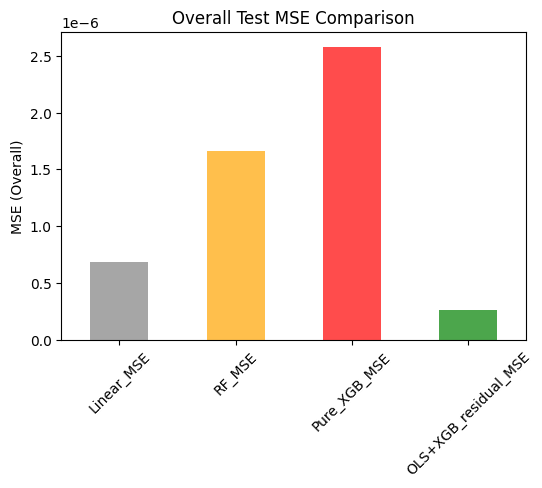

In [65]:
import matplotlib.pyplot as plt

def plot_overall_mse(table):
    overall = table.loc["OVERALL", ["Linear_MSE","RF_MSE","Pure_XGB_MSE","OLS+XGB_residual_MSE"]]
    overall.plot(kind="bar", figsize=(6,4), color=["gray","orange","red","green"], alpha=0.7)
    plt.ylabel("MSE (Overall)")
    plt.title("Overall Test MSE Comparison")
    plt.xticks(rotation=45)
    plt.show()
plot_overall_mse(table)


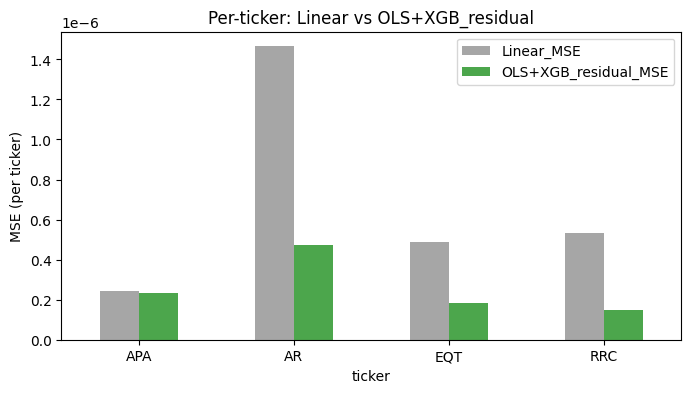

In [66]:
def plot_per_ticker_mse(table):
    per_ticker = table.drop("OVERALL")
    per_ticker[["Linear_MSE","OLS+XGB_residual_MSE"]].plot(
        kind="bar", figsize=(8,4), color=["gray","green"], alpha=0.7
    )
    plt.ylabel("MSE (per ticker)")
    plt.title("Per-ticker: Linear vs OLS+XGB_residual")
    plt.xticks(rotation=0)
    plt.show()

plot_per_ticker_mse(table)


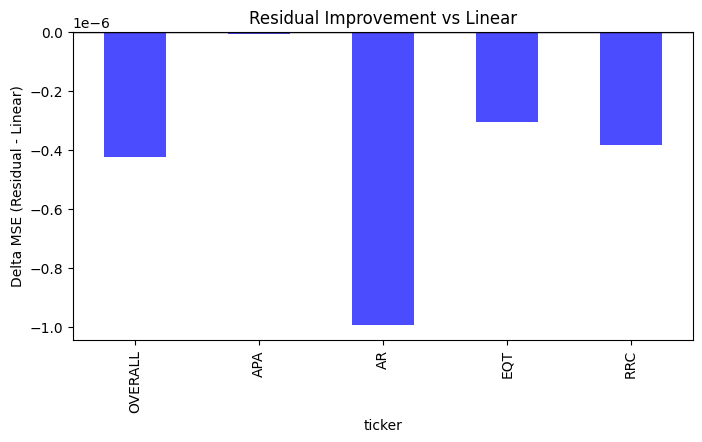

In [67]:
def plot_delta_vs_linear(table):
    table["Delta_resid_vs_linear"].plot(kind="bar", figsize=(8,4), color="blue", alpha=0.7)
    plt.axhline(0, color="black", linewidth=1)
    plt.ylabel("Delta MSE (Residual - Linear)")
    plt.title("Residual Improvement vs Linear")
    plt.show()
plot_delta_vs_linear(table)


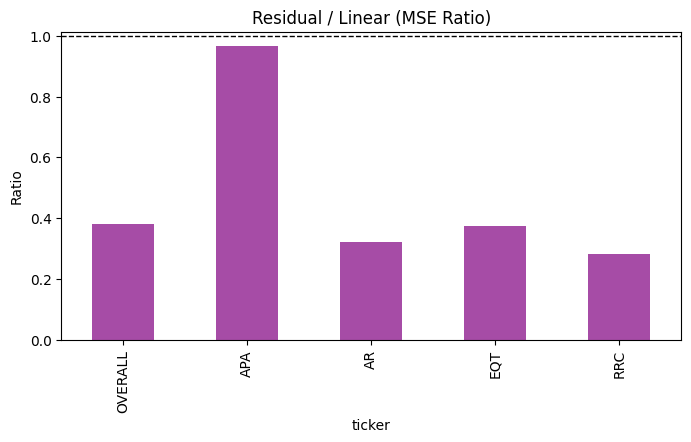

In [68]:
def plot_ratio_vs_linear(table):
    table["Ratio_resid_vs_linear"].plot(kind="bar", figsize=(8,4), color="purple", alpha=0.7)
    plt.axhline(1, color="black", linewidth=1, linestyle="--")
    plt.ylabel("Ratio")
    plt.title("Residual / Linear (MSE Ratio)")
    plt.show()
plot_ratio_vs_linear(table)